# vis2d Color Tuning

This notebook focuses on `vis2d` color control:

1. the new default low-saturation palette,
2. one-off fill / edge overrides on a single `vis2d(...)` call,
3. scoped default overrides with `braincell.vis.theme(...)`.


In [1]:
import os
os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import braincell
import brainunit as u
import matplotlib.pyplot as plt

from braincell import Branch, Morphology


ERROR:2026-04-25 16:53:22,328:jax._src.xla_bridge:444: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax/_src/xla_bridge.py", line 442, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 324, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 257, in _check_cuda_versions
    cublas_version = _version_check("cuBLAS", cuda_versions.cublas_get_version,
  File "/home/swl/anaconda3/envs/braincell/lib/python3.10/site-packages/jax_plugins/xla_cuda12/__init__.py", line 217, in _version_check
    raise RuntimeError(msg)
RuntimeError: Outdated cuBLAS installation found.
Version JAX was built against: 12

In [2]:
def make_tree() -> Morphology:
    soma = Branch.from_points(
        points=[[0.0, 0.0, 0.0], [20.0, 0.0, 0.0]] * u.um,
        radii=[10.0, 10.0] * u.um,
        type='soma',
    )
    apical = Branch.from_points(
        points=[[20.0, 0.0, 0.0], [20.0, 35.0, 0.0], [20.0, 80.0, 0.0]] * u.um,
        radii=[3.0, 2.2, 1.6] * u.um,
        type='apical_dendrite',
    )
    basal = Branch.from_points(
        points=[[0.0, 0.0, 0.0], [-18.0, -22.0, 0.0], [-35.0, -34.0, 0.0]] * u.um,
        radii=[2.0, 1.6, 1.2] * u.um,
        type='basal_dendrite',
    )
    axon = Branch.from_points(
        points=[[0.0, 0.0, 0.0], [0.0, -28.0, 0.0], [0.0, -60.0, 0.0]] * u.um,
        radii=[1.1, 0.8, 0.6] * u.um,
        type='axon',
    )
    tree = Morphology.from_root(soma, name='soma')
    tree.attach(parent='soma', child_branch=apical, child_name='apical', parent_x=1.0)
    tree.attach(parent='soma', child_branch=basal, child_name='basal', parent_x=1.0)
    tree.attach(parent='soma', child_branch=axon, child_name='axon', parent_x=0.0)
    return tree


tree = make_tree()


## 1. Default palette

The default 2D palette is now lower saturation, and `shape='frustum'`
uses a darker edge color by default instead of reusing the fill color.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


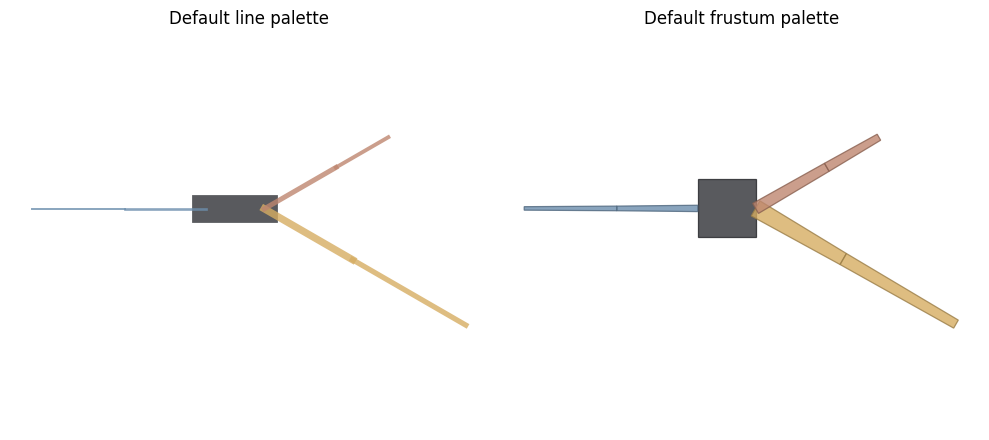

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

tree.vis2d(shape='line', ax=axes[0], show=False)
axes[0].set_title('Default line palette')

tree.vis2d(shape='frustum', ax=axes[1], show=False)
axes[1].set_title('Default frustum palette')

fig.tight_layout()


## 2. One-off overrides on `vis2d(...)`

Use `branch_type_colors`, `branch_type_edge_colors_2d`, and
`frustum_edge_linewidth_2d` to tune a single render call without
changing global defaults.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


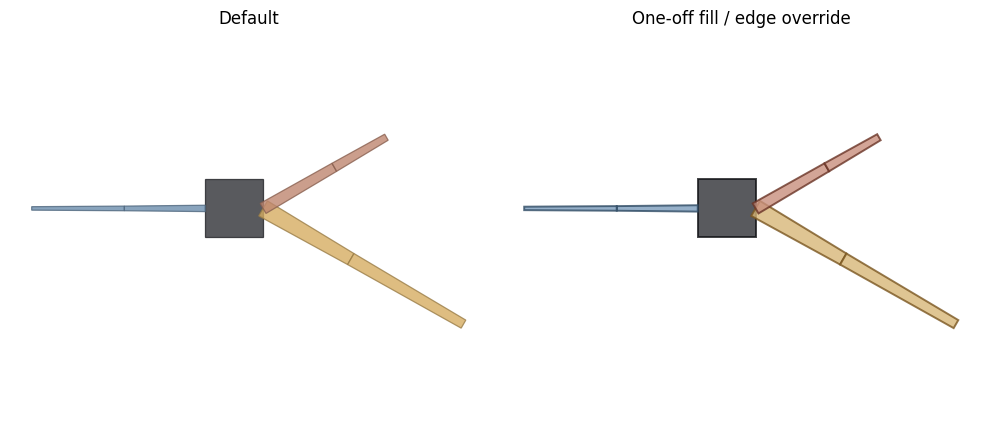

In [4]:
fill_colors = {
    'soma': '#2f3136',
    'apical_dendrite': '#d8b778',
    'basal_dendrite': '#c88f7d',
    'axon': '#7c9dbc',
}
edge_colors = {
    'soma': '#101215',
    'apical_dendrite': '#7a5620',
    'basal_dendrite': '#6a3426',
    'axon': '#2e4a63',
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

tree.vis2d(shape='frustum', ax=axes[0], show=False)
axes[0].set_title('Default')

tree.vis2d(
    shape='frustum',
    branch_type_colors=fill_colors,
    branch_type_edge_colors_2d=edge_colors,
    frustum_edge_linewidth_2d=1.4,
    ax=axes[1],
    show=False,
)
axes[1].set_title('One-off fill / edge override')

fig.tight_layout()


## 3. Scoped defaults with `braincell.vis.theme(...)`

If you want several plots to share the same look, wrap them in
`braincell.vis.theme(...)`. The shared `branch_type_colors` palette
drives 2D fills/lines, 3D branch colors, and branch-type topology plots;
the global defaults are restored automatically on exit.


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


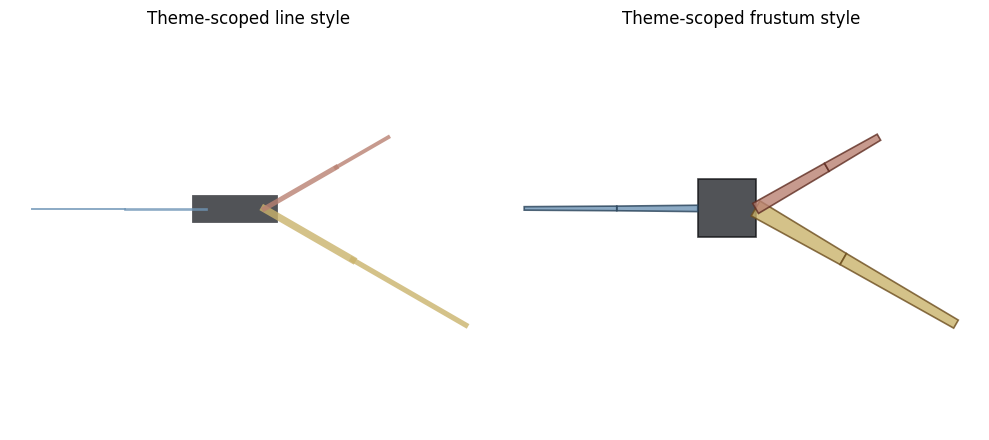

In [5]:
with braincell.vis.theme(
    branch_type_colors={
        'soma': '#26282d',
        'apical_dendrite': '#cab36c',
        'basal_dendrite': '#b98172',
        'axon': '#6f95b6',
    },
    branch_type_edge_colors_2d={
        'soma': '#0f1013',
        'apical_dendrite': '#6c4d1e',
        'basal_dendrite': '#5f2d22',
        'axon': '#274158',
    },
    frustum_edge_linewidth_2d=1.2,
):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    tree.vis2d(shape='line', ax=axes[0], show=False)
    axes[0].set_title('Theme-scoped line style')
    tree.vis2d(shape='frustum', ax=axes[1], show=False)
    axes[1].set_title('Theme-scoped frustum style')
    fig.tight_layout()
